In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproducibility
np.random.seed(42)

# Paths
RAW_DATA_PATH = Path("../data/raw")
RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Date range — 2 years of weekly data
dates = pd.date_range(start="2022-01-03", periods=104, freq="W-MON")

print(f"Dataset spans: {dates[0].date()} to {dates[-1].date()}")
print(f"Total weeks: {len(dates)}")

Dataset spans: 2022-01-03 to 2023-12-25
Total weeks: 104


# Base weekly revenue — Ovela is a growing brand, so we add a gentle upward trend

Average weekly revenue: $100,057
Min: $81,506  |  Max: $117,593


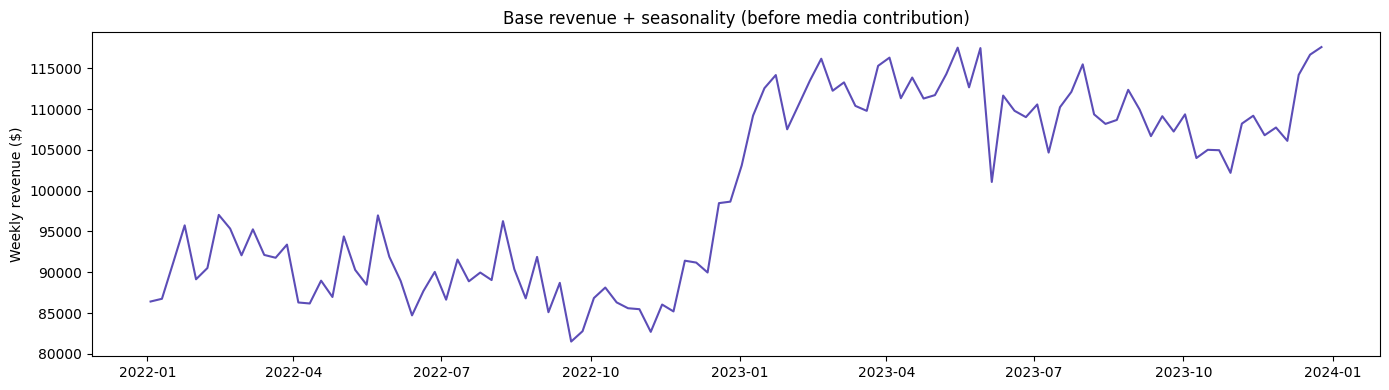

In [ ]:
base_revenue = 80000  # starting weekly revenue
trend = np.linspace(0, 40000, 104)  # grows ~$40K over 2 years

# Seasonality — fertility brands have real seasonal patterns
# Peaks: January (new year resolutions), May (fertility awareness month),
# September (back to routine), dip in late November (Thanksgiving disruption)
week_of_year = pd.Series(dates).dt.isocalendar().week.values

seasonality = (
    8000 * np.sin(2 * np.pi * week_of_year / 52)        # broad annual wave
    + 4000 * np.sin(4 * np.pi * week_of_year / 52)      # secondary mid-year bump
    + 3000 * ((week_of_year >= 1) & (week_of_year <= 4)) # January resolution spike
    + 4000 * ((week_of_year >= 18) & (week_of_year <= 22)) # May awareness month
    - 3000 * ((week_of_year >= 47) & (week_of_year <= 49)) # Thanksgiving dip
)

# Random noise — real revenue is never perfectly smooth
noise = np.random.normal(0, 3000, 104)

# Combine
base = base_revenue + trend + seasonality + noise
base = np.clip(base, 50000, None)  # floor at $50K — brand never falls below this

print(f"Average weekly revenue: ${base.mean():,.0f}")
print(f"Min: ${base.min():,.0f}  |  Max: ${base.max():,.0f}")

# Quick plot to sanity check the shape
plt.figure(figsize=(14, 4))
plt.plot(dates, base, color="#5C4DB7", linewidth=1.5)
plt.title("Base revenue + seasonality (before media contribution)")
plt.ylabel("Weekly revenue ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

# Channel & Spend Data

Average weekly spend by channel:
  Meta         $  18,730  |  total: $ 1,947,960
  Google       $  12,064  |  total: $ 1,254,698
  TikTok       $   8,073  |  total: $   839,616
  Email        $   1,566  |  total: $   162,884
  Influencer   $   1,673  |  total: $   174,000

Total 2-year media spend: $4,379,158


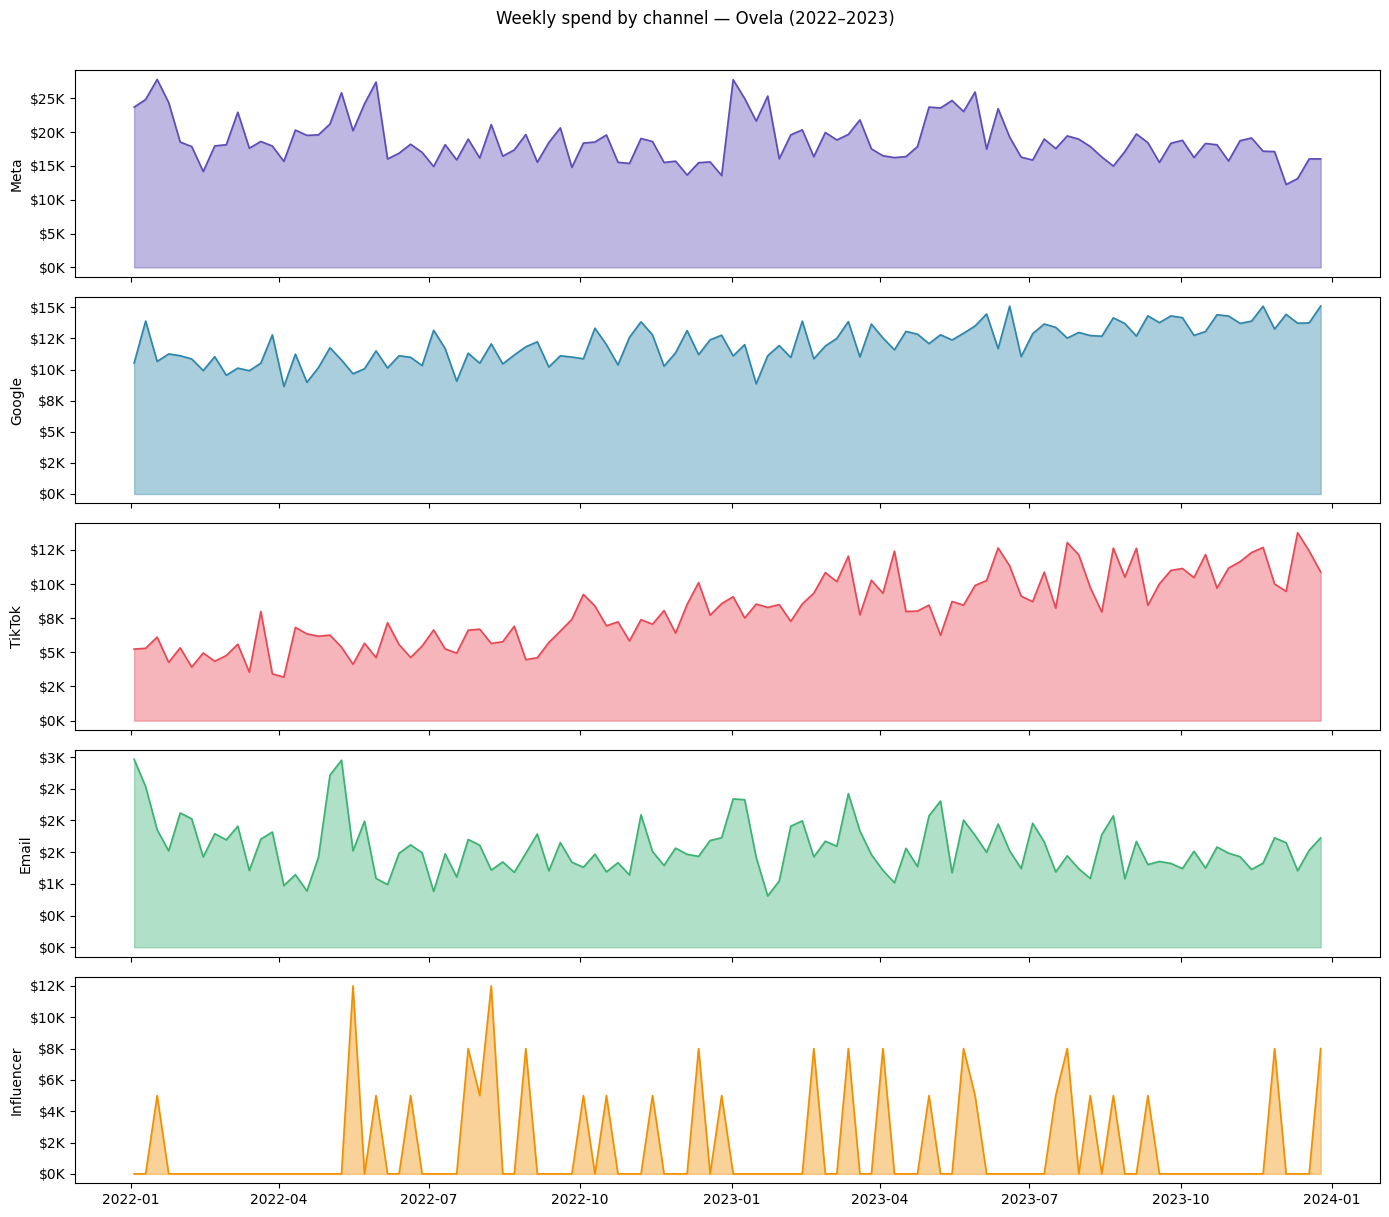

In [3]:
# Weekly spend per channel — realistic for a DTC brand at this revenue scale
# Meta is the dominant channel, Google is efficient, TikTok is growing,
# email is low cost, influencer is sporadic

# Meta — largest budget, some week-to-week variation, heavier in Jan and May
meta_base = 18000
meta_spend = (
    meta_base
    + np.random.normal(0, 2000, 104)
    + 6000 * ((week_of_year >= 1) & (week_of_year <= 4))    # January push
    + 5000 * ((week_of_year >= 18) & (week_of_year <= 22))  # May push
    - 3000 * ((week_of_year >= 47) & (week_of_year <= 52))  # Q4 pullback
)
meta_spend = np.clip(meta_spend, 8000, None)

# Google — steady, less volatile, grows slightly over time
google_base = 10000
google_spend = (
    google_base
    + np.linspace(0, 4000, 104)                             # gradual budget increase
    + np.random.normal(0, 1000, 104)
)
google_spend = np.clip(google_spend, 6000, None)

# TikTok — small and growing, brand is still testing this channel
tiktok_base = 4000
tiktok_spend = (
    tiktok_base
    + np.linspace(0, 8000, 104)                             # ramps up significantly
    + np.random.normal(0, 1500, 104)
)
tiktok_spend = np.clip(tiktok_spend, 0, None)

# Email — very low cost, relatively flat, slight uplift around campaigns
email_spend = (
    1500
    + np.random.normal(0, 300, 104)
    + 1000 * ((week_of_year >= 1) & (week_of_year <= 2))    # New Year campaign
    + 1000 * ((week_of_year >= 18) & (week_of_year <= 19))  # May campaign
)
email_spend = np.clip(email_spend, 500, None)

# Influencer — sporadic, larger bursts a few times a year
influencer_spend = np.random.choice(
    [0, 0, 0, 5000, 8000, 12000], size=104,
    p=[0.5, 0.15, 0.1, 0.1, 0.1, 0.05]
)

# Print spend summary
channels = {
    "Meta": meta_spend,
    "Google": google_spend,
    "TikTok": tiktok_spend,
    "Email": email_spend,
    "Influencer": influencer_spend
}

print("Average weekly spend by channel:")
for name, spend in channels.items():
    print(f"  {name:<12} ${spend.mean():>8,.0f}  |  total: ${spend.sum():>10,.0f}")

total_spend = sum(spend.sum() for spend in channels.values())
print(f"\nTotal 2-year media spend: ${total_spend:,.0f}")

# Plot spend over time
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
colors = ["#5C4DB7", "#2E86AB", "#E84855", "#3BB273", "#F18F01"]

for ax, (name, spend), color in zip(axes, channels.items(), colors):
    ax.fill_between(dates, spend, alpha=0.4, color=color)
    ax.plot(dates, spend, color=color, linewidth=1.2)
    ax.set_ylabel(name, fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
    )

axes[-1].set_xlabel("")
fig.suptitle("Weekly spend by channel — Ovela (2022–2023)", y=1.01)
plt.tight_layout()
plt.show()

# Revenue response and final dataframe

In [4]:
# Now we build the actual revenue that each channel drives
# This is the "ground truth" we'll later try to recover with the MMM
# Each channel has a different efficiency (ROI) and carryover effect

def adstock_transform(spend, decay_rate):
    """
    Geometric adstock — captures the carryover effect of advertising.
    A campaign this week still drives some revenue next week and beyond.
    decay_rate: how much effect carries over (0 = no carryover, 0.9 = slow decay)
    """
    adstocked = np.zeros_like(spend, dtype=float)
    adstocked[0] = spend[0]
    for t in range(1, len(spend)):
        adstocked[t] = spend[t] + decay_rate * adstocked[t - 1]
    return adstocked

def saturation_transform(spend, alpha, gamma):
    """
    Hill function — captures diminishing returns.
    At low spend, each dollar is very effective.
    At high spend, incremental returns flatten out.
    alpha: inflection point (spend level where returns start diminishing)
    gamma: shape of the curve (higher = steeper initial climb)
    """
    return spend ** gamma / (alpha ** gamma + spend ** gamma)

# Apply adstock to each channel (different decay rates reflect channel nature)
meta_adstocked      = adstock_transform(meta_spend,       decay_rate=0.5)
google_adstocked    = adstock_transform(google_spend,     decay_rate=0.3)
tiktok_adstocked    = adstock_transform(tiktok_spend,     decay_rate=0.4)
email_adstocked     = adstock_transform(email_spend,      decay_rate=0.2)
influencer_adstocked = adstock_transform(influencer_spend, decay_rate=0.6)

# Apply saturation to each channel
meta_saturated       = saturation_transform(meta_adstocked,       alpha=25000, gamma=0.7)
google_saturated     = saturation_transform(google_adstocked,     alpha=15000, gamma=0.8)
tiktok_saturated     = saturation_transform(tiktok_adstocked,     alpha=10000, gamma=0.75)
email_saturated      = saturation_transform(email_adstocked,      alpha=3000,  gamma=0.9)
influencer_saturated = saturation_transform(influencer_adstocked, alpha=8000,  gamma=0.65)

# Revenue contribution per channel — these are the true coefficients
# Meta is big but increasingly saturated
# Google is efficient — high return per dollar
# TikTok is growing but still maturing
# Email punches above its weight
# Influencer is variable and hard to attribute

meta_contrib        = 38000 * meta_saturated
google_contrib      = 52000 * google_saturated
tiktok_contrib      = 28000 * tiktok_saturated
email_contrib       = 22000 * email_saturated
influencer_contrib  = 18000 * influencer_saturated

# One-time promo event — Ovela ran a sitewide sale in week 40 of 2022
promo_flag = np.zeros(104)
promo_flag[39] = 1  # week index 39 = ~October 2022
promo_effect = 15000 * promo_flag

# Total revenue = base + all channel contributions + promo
revenue = (
    base
    + meta_contrib
    + google_contrib
    + tiktok_contrib
    + email_contrib
    + influencer_contrib
    + promo_effect
)

# Assemble the final dataframe
df = pd.DataFrame({
    "date":               dates,
    "revenue":            revenue.round(2),
    "meta_spend":         meta_spend.round(2),
    "google_spend":       google_spend.round(2),
    "tiktok_spend":       tiktok_spend.round(2),
    "email_spend":        email_spend.round(2),
    "influencer_spend":   influencer_spend.round(2),
    "promo_flag":         promo_flag.astype(int),
    "week_of_year":       week_of_year,
    "year":               pd.Series(dates).dt.year.values,
})

# Sanity check
print(df.shape)
print(f"\nRevenue range: ${df.revenue.min():,.0f} — ${df.revenue.max():,.0f}")
print(f"Average weekly revenue: ${df.revenue.mean():,.0f}")
print(f"\nFirst 5 rows:")
df.head()

(104, 10)

Revenue range: $148,993 — $204,946
Average weekly revenue: $178,887

First 5 rows:


,date,revenue,meta_spend,google_spend,tiktok_spend,email_spend,influencer_spend,promo_flag,week_of_year,year
0,2022-01-03,148993.16,23677.43,10515.05,5238.12,2965.35,0,0,1,2022
1,2022-01-10,159231.42,24808.10,13891.57,5297.93,2534.70,0,0,2,2022
2,2022-01-17,171915.14,27772.37,10648.56,6113.56,1853.79,5000,0,3,2022
3,2022-01-24,173625.45,24349.16,11252.07,4264.52,1520.26,0,0,4,2022
4,2022-01-31,166421.99,18515.10,11109.34,5333.61,2118.22,0,0,5,2022


# Contribution breakdown chart and export

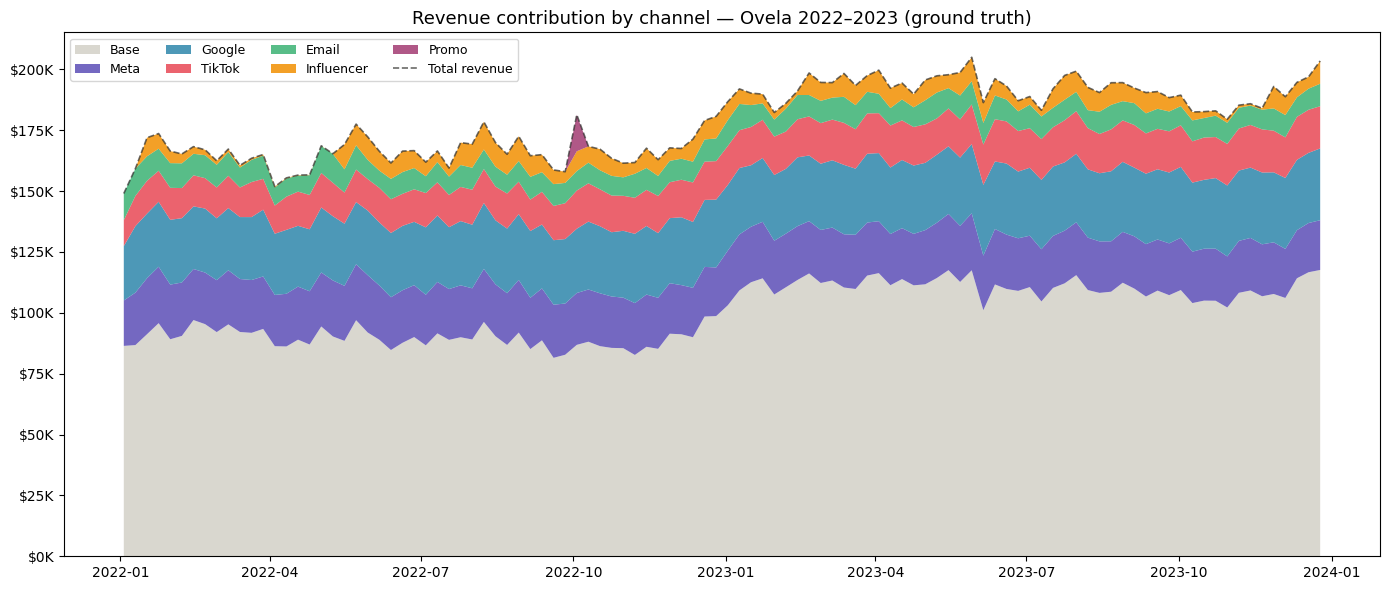

Chart saved.

True average weekly contribution by channel:
  Base         $ 100,057  (55.9%)
  Meta         $  21,562  (12.1%)
  Google       $  27,314  (15.3%)
  TikTok       $  15,226  (8.5%)
  Email        $   8,807  (4.9%)
  Influencer   $   5,776  (3.2%)
  Promo        $     144  (0.1%)


In [5]:
# Stacked contribution chart — this is the "ground truth" decomposition
# In Phase 3 we'll try to recover these contributions with the MMM

contributions = pd.DataFrame({
    "date":        dates,
    "Base":        base.round(2),
    "Meta":        meta_contrib.round(2),
    "Google":      google_contrib.round(2),
    "TikTok":      tiktok_contrib.round(2),
    "Email":       email_contrib.round(2),
    "Influencer":  influencer_contrib.round(2),
    "Promo":       promo_effect.round(2),
})

# Stacked area chart
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    "Base":       "#D3D1C7",
    "Meta":       "#5C4DB7",
    "Google":     "#2E86AB",
    "TikTok":     "#E84855",
    "Email":      "#3BB273",
    "Influencer": "#F18F01",
    "Promo":      "#A23B72",
}

channels_ordered = ["Base", "Meta", "Google", "TikTok", "Email", "Influencer", "Promo"]

ax.stackplot(
    contributions["date"],
    [contributions[c] for c in channels_ordered],
    labels=channels_ordered,
    colors=[colors[c] for c in channels_ordered],
    alpha=0.85
)

ax.plot(dates, revenue, color="#2C2C2A", linewidth=1.2,
        linestyle="--", label="Total revenue", alpha=0.7)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
)
ax.set_title("Revenue contribution by channel — Ovela 2022–2023 (ground truth)",
             fontsize=13)
ax.legend(loc="upper left", fontsize=9, ncol=4)
ax.set_xlabel("")
plt.tight_layout()

# Save chart
output_path = Path("../outputs/charts")
output_path.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path / "01_contribution_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

# Print true contribution percentages — useful to reference later when
# comparing against what the MMM recovers
print("\nTrue average weekly contribution by channel:")
total_avg = revenue.mean()
for c in channels_ordered:
    avg = contributions[c].mean()
    pct = avg / total_avg * 100
    print(f"  {c:<12} ${avg:>8,.0f}  ({pct:.1f}%)")

In [6]:
# Export to data/raw/
df.to_csv(RAW_DATA_PATH / "ovela_weekly_data.csv", index=False)
print(f"Exported {len(df)} rows to data/raw/ovela_weekly_data.csv")
print("\nColumns:")
for col in df.columns:
    print(f"  {col}")

Exported 104 rows to data/raw/ovela_weekly_data.csv

Columns:
  date
  revenue
  meta_spend
  google_spend
  tiktok_spend
  email_spend
  influencer_spend
  promo_flag
  week_of_year
  year
